In [45]:
import csv
import pandas as pd

## task 1.1 Data Exploration 

In [46]:
raw_df = pd.read_csv(
    "Algerian_forest_fires_dataset_UPDATE.csv",
    header=None,
    names=range(14),
    skip_blank_lines=False,
    dtype=str,
)

raw_df


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Bejaia Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
2,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
3,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
4,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
245,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
246,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
247,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [47]:
'''Variable Name	Role	Type	Description	Units	Missing Values
region	Feature	Categorical	Bejaia or Sidi-Bel Abbes		no
day	Feature	Integer			no
month	Feature	Integer			no
year	Feature	Integer			no
Temperature	Feature	Integer	temperature noon	C	no
RH	Feature	Integer	relative humidity	%	no
Ws	Feature	Integer	wind speed	km/h	no
Rain	Feature	Continuous		mm	no
FFMC	Feature	Continuous	Fine Fuel Moisture Code		no
DMC	Feature	Continuous	Duff Moisture Code		no
DC	Feature	Continuous	Drought Code		no
ISI	Feature	Continuous	Initial Spread Index		no
BUI	Feature	Continuous	Buildup Index		no
FWI	Feature	Continuous	Fire Weather Index		no
Classes	Target	Categorical			no'''

'Variable Name\tRole\tType\tDescription\tUnits\tMissing Values\nregion\tFeature\tCategorical\tBejaia or Sidi-Bel Abbes\t\tno\nday\tFeature\tInteger\t\t\tno\nmonth\tFeature\tInteger\t\t\tno\nyear\tFeature\tInteger\t\t\tno\nTemperature\tFeature\tInteger\ttemperature noon\tC\tno\nRH\tFeature\tInteger\trelative humidity\t%\tno\nWs\tFeature\tInteger\twind speed\tkm/h\tno\nRain\tFeature\tContinuous\t\tmm\tno\nFFMC\tFeature\tContinuous\tFine Fuel Moisture Code\t\tno\nDMC\tFeature\tContinuous\tDuff Moisture Code\t\tno\nDC\tFeature\tContinuous\tDrought Code\t\tno\nISI\tFeature\tContinuous\tInitial Spread Index\t\tno\nBUI\tFeature\tContinuous\tBuildup Index\t\tno\nFWI\tFeature\tContinuous\tFire Weather Index\t\tno\nClasses\tTarget\tCategorical\t\t\tno'

#### we can observe from the head that the region name is conisdered as the first row and it doesnt make sense for us to keep it that way since it will be difficult in working with it as a pandas dataframe, so we shall ignore that row and club the date into a single collumn and give it an index column so that the data can be differentiated between regions

In [48]:
# rows holding a region title have text only in the first column
region_title_mask = raw_df[0].str.contains("Region Dataset", na=False)
region_per_row = raw_df[0].where(region_title_mask).ffill()#filling the region for each row

header = [h.strip() for h in raw_df.iloc[1]]

data_mask = ~region_title_mask & (raw_df[0].str.strip() != header[0]) & raw_df[0].notna()
df = raw_df[data_mask].copy()
df.columns = header
df["region"] = region_per_row[data_mask].str.split(" Region").str[0].values
df = df.reset_index(drop=True)
df



,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,Bejaia
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,Bejaia
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,Bejaia
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,Bejaia
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,Bejaia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,Sidi-Bel Abbes
240,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,Sidi-Bel Abbes
241,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,Sidi-Bel Abbes
242,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,Sidi-Bel Abbes


In [49]:
df["date"] = pd.to_datetime(
    df["day"] + "-" + df["month"] + "-" + df["year"], format="%d-%m-%Y"
)
df_new = df.drop(columns=["day", "month", "year"], inplace=False)
df_new

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region,date
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,Bejaia,2012-06-01
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,Bejaia,2012-06-02
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,Bejaia,2012-06-03
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,Bejaia,2012-06-04
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,Bejaia,2012-06-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,Sidi-Bel Abbes,2012-09-26
240,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,Sidi-Bel Abbes,2012-09-27
241,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,Sidi-Bel Abbes,2012-09-28
242,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,Sidi-Bel Abbes,2012-09-29


In [50]:
features = ["Temperature", "RH", "Ws", "Rain", "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]
df_new[features] = df_new[features].apply(pd.to_numeric, errors="coerce")
df_new["Classes"] = df_new["Classes"].str.strip()

<Axes: >

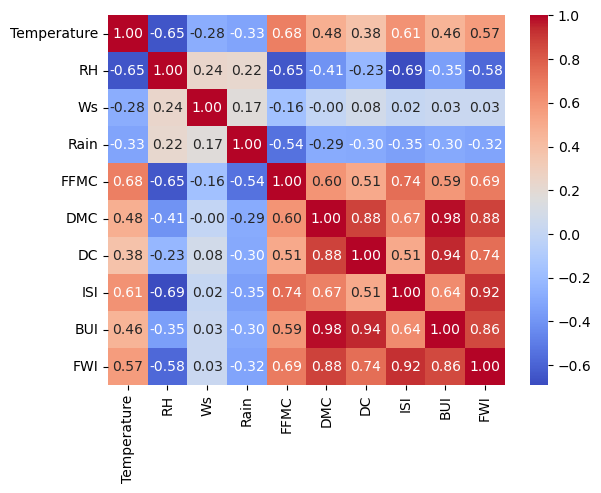

In [51]:
import seaborn as sns
sns.heatmap(df_new.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm")

##### heatmap is the best way to find the relationship between the collumns higher the value means closer influence on its corresponding parameter.

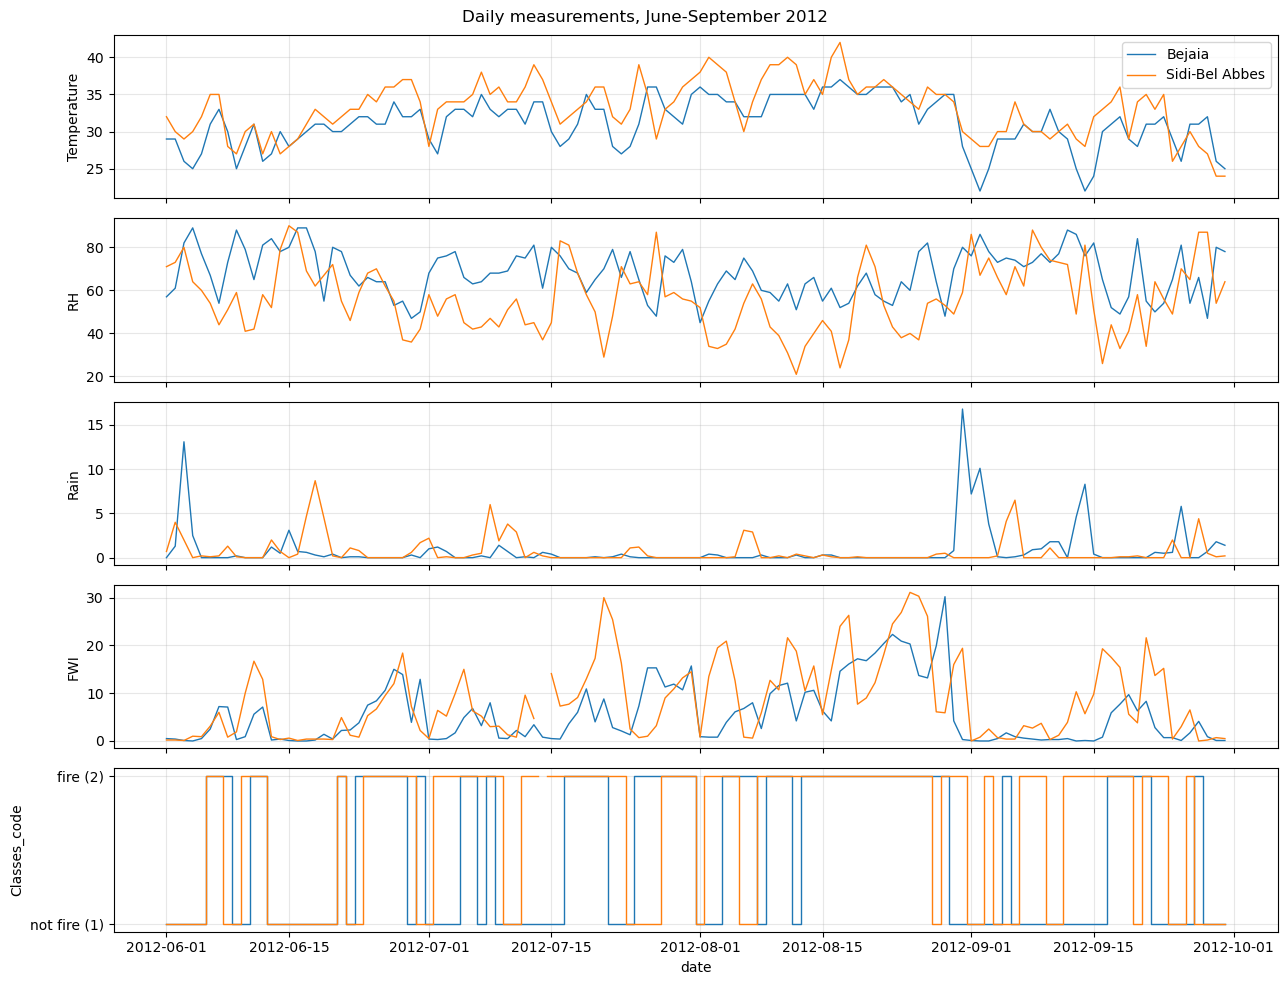

In [52]:
import matplotlib.pyplot as plt

# matplotlib cannot mix the text labels with numeric axes, so encode them
df_new["Classes_code"] = df_new["Classes"].map({"not fire": 1, "fire": 2})

plot_cols = ["Temperature", "RH", "Rain", "FWI", "Classes_code"]
regions = df_new["region"].unique()

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(13, 10), sharex=True)
for ax, col in zip(axes, plot_cols):
    for region in regions:
        g = df_new[df_new["region"] == region].sort_values("date")
        if col == "Classes_code":
            ax.step(g["date"], g[col], where="mid", label=region, linewidth=1)
        else:
            ax.plot(g["date"], g[col], label=region, linewidth=1)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_yticks([1, 2])
axes[-1].set_yticklabels(["not fire (1)", "fire (2)"])
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("date")
fig.suptitle("Daily measurements, June-September 2012")
fig.tight_layout()
plt.show()


#### better understanding of the parameters date wise, we can see a clear correlation between rain and temperature during the same date, it is obvious that the temperatures come down when it rains and so on. 

In [53]:
# the date is spread across different collumns, 
# we need to combine them into a single column for easier processing
#the data is concatinated into a single file which contains data about different regions of Algeria
# we will now proceed to clean and preprocess the data for analysis
#since the data has an empty row that separates different regions, we need to remove these empty rows before analysis 
#and create separate DataFrames for each region or we remove that empty row entirely and make is one big DataFrame for the entire dataset

In [54]:
#since the data is time series we can index them by date or time for easier analysis and visualization
#we can use evident indexes such that both regions are distinguishable

#this will helpus with the data exploration and visualization of trends over time

### task  1.2

In [55]:
# empty strings survive read_csv, so count them separately from real NaNs
blank_mask = df_new.astype(str).apply(lambda s: s.str.strip().eq(""))

missing = pd.DataFrame({
    "nan_count": df_new.isna().sum(),
    "blank_count": blank_mask.sum(),
    "dtype": df_new.dtypes,
})
missing["total_missing"] = missing["nan_count"] + missing["blank_count"]
print(missing)

print("\nrows with any missing value:")
rows_with_missing = df_new[df_new.isna().any(axis=1) | blank_mask.any(axis=1)]
rows_with_missing


              nan_count  blank_count           dtype  total_missing
Temperature           0            0           int64              0
RH                    0            0           int64              0
Ws                    0            0           int64              0
Rain                  0            0         float64              0
FFMC                  0            0         float64              0
DMC                   0            0         float64              0
DC                    1            0         float64              1
ISI                   0            0         float64              0
BUI                   0            0         float64              0
FWI                   1            0         float64              1
Classes               1            0          object              1
region                0            0          object              0
date                  0            0  datetime64[ns]              0
Classes_code          1            0         flo

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region,date,Classes_code
165,37,37,18,0.2,88.9,12.9,NaN,12.5,10.4,NaN,NaN,Sidi-Bel Abbes,2012-07-14,NaN


In [43]:
#for handling of missing values in the time series data
#we can use techniques like forward fill, backward fill, or interpolation depending on the nature of the data
#it's important to choose the method that preserves the integrity of the time series patterns 

### task 1.3

In [44]:
#for preprocessing the time series data we can start by setting the date or time column as the index
#this will allow us to easily handle missing values, resample the data, and perform time-based analysis 
#find the approprate collumn that influences the prediction
#this will help in selecting the target variable and relevant features for the model. and also remove irrelevant columns.